<a href="https://colab.research.google.com/github/winarwahyuw/data-science-250401020025-winar-wahyu-wulansari/blob/main/Data_Science_Pertemuan_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## PERTEMUAN 5
#### Nama : Winar Wahyu Wulansari
#### NIM : 250401020025
#### Kelas : IF405


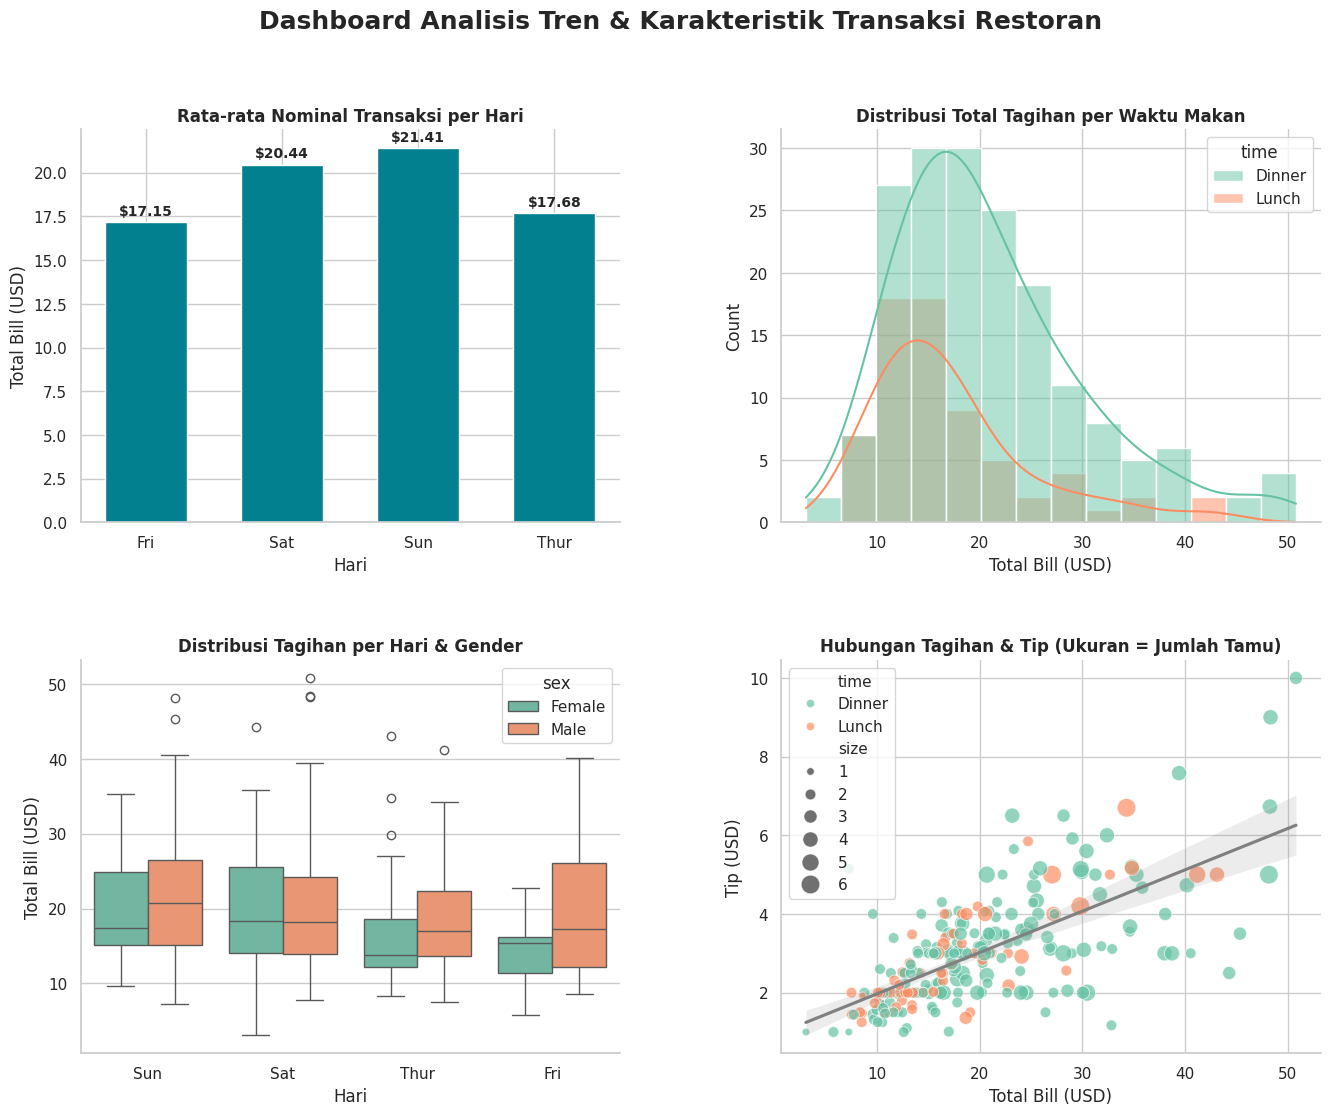

In [30]:
# Memaksa inline plotting agar grafik langsung muncul di bawah sel Colab
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Mengatur tema visualisasi agar konsisten dan rapi
sns.set_theme(style='whitegrid', palette='Set2')

# Memuat dataset 'tips' bawaan dari Seaborn
df = sns.load_dataset('tips')

# PERBAIKAN UTAMA: Mengubah kolom kategori menjadi tipe string/object biasa
# agar terbaca dengan sempurna oleh fungsi grouping dan grafik Seaborn
df['day'] = df['day'].astype(str)
df['time'] = df['time'].astype(str)
df['sex'] = df['sex'].astype(str)

# Inisialisasi kanvas utama (Figure) dengan ukuran proporsional
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Tren & Karakteristik Transaksi Restoran',
             fontsize=18, fontweight='bold', y=0.98)

# Mengatur tata letak Grid Layout (2 baris x 2 kolom)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# Deklarasi masing-masing panel plot (Axes)
ax1 = fig.add_subplot(gs[0, 0]) # Kiri Atas
ax2 = fig.add_subplot(gs[0, 1]) # Kanan Atas
ax3 = fig.add_subplot(gs[1, 0]) # Kiri Bawah
ax4 = fig.add_subplot(gs[1, 1]) # Kanan Bawah

# ------------------------------------------------------------------------------
# GRAFIK 1: Bar Chart (Rata-rata Total Tagihan per Hari)
# ------------------------------------------------------------------------------
# Menggunakan observed=False agar pengelompokan string berjalan lancar
avg_by_day = df.groupby('day', observed=False)['total_bill'].mean()
bars = ax1.bar(avg_by_day.index, avg_by_day.values, color='#028090', edgecolor='white', width=0.6)
ax1.set_title('Rata-rata Nominal Transaksi per Hari', fontsize=12, fontweight='bold')
ax1.set_xlabel('Hari')
ax1.set_ylabel('Total Bill (USD)')
ax1.spines[['top', 'right']].set_visible(False)
ax1.bar_label(bars, fmt='$%.2f', padding=3, fontsize=10, fontweight='bold')

# ------------------------------------------------------------------------------
# GRAFIK 2: Histogram + KDE (Distribusi Total Tagihan per Waktu Makan)
# ------------------------------------------------------------------------------
sns.histplot(data=df, x='total_bill', hue='time', kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Total Tagihan per Waktu Makan', fontsize=12, fontweight='bold')
ax2.set_xlabel('Total Bill (USD)')
ax2.spines[['top', 'right']].set_visible(False)

# ------------------------------------------------------------------------------
# GRAFIK 3: Boxplot (Distribusi Tagihan per Hari & Gender)
# ------------------------------------------------------------------------------
sns.boxplot(data=df, x='day', y='total_bill', hue='sex', palette='Set2', ax=ax3)
ax3.set_title('Distribusi Tagihan per Hari & Gender', fontsize=12, fontweight='bold')
ax3.set_xlabel('Hari')
ax3.set_ylabel('Total Bill (USD)')
ax3.spines[['top', 'right']].set_visible(False)

# ------------------------------------------------------------------------------
# GRAFIK 4: Scatter Plot (Hubungan Tagihan & Tip)
# ------------------------------------------------------------------------------
sns.scatterplot(data=df, x='total_bill', y='tip', hue='time', size='size',
                sizes=(30, 180), palette='Set2', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='total_bill', y='tip', scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Tagihan & Tip (Ukuran = Jumlah Tamu)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Total Bill (USD)')
ax4.set_ylabel('Tip (USD)')
ax4.spines[['top', 'right']].set_visible(False)

# Tampilkan seluruh grafik secara langsung di output Google Colab
plt.show()

## Kesimpulan & Analisis Hasil Dashboard

### 1. Ringkasan Data & Pola Distribusi
* **Ukuran Kelopak (`sepal_length` & `sepal_width`)**: Memiliki nilai rata-rata dan median yang sangat dekat, dengan tingkat kemiringan (*skewness*) yang normal. Pola distribusinya simetris (membentuk kurva lonceng), menunjukkan ukuran kelopak tanaman ini cukup konsisten di alam.
* **Ukuran Mahkota (`petal_length` & `petal_width`)**: Memiliki variasi data yang tinggi dan nilai keruncingan (*kurtosis*) yang sangat negatif. Hal ini menandakan adanya distribusi Bimodal (dua puncak terpisah) karena karakteristik ukuran mahkota antar spesies berbeda sangat drastis.

### 2. Variasi Ukuran Berdasarkan Spesies
Berdasarkan visualisasi Boxplot dan Violin Plot, terlihat pengelompokan fisik bunga yang jelas:
* **Iris Setosa**: Memiliki ukuran mahkota paling kecil dan seragam (datanya berkumpul rapat di area bawah grafik).
* **Iris Virginica**: Memiliki ukuran mahkota paling besar (datanya berkumpul di area atas grafik).
* **Iris Versicolor**: Berada di posisi menengah, namun memiliki rentang data yang paling lebar. Artinya, variasi ukuran pada jenis ini adalah yang paling dinamis.

### 3. Hubungan Antar Variabel (Korelasi & Scatter Plot)
* **Hubungan Terkuat**: Ditemukan pada hubungan sesama ukuran mahkota (panjang vs lebar) dengan nilai korelasi mencapai 0.963. Hubungan positif yang sangat kuat ini menunjukkan bahwa ketika mahkota tumbuh memanjang, ukurannya otomatis juga akan melebar secara proporsional.
* **Hubungan Terlemah**: Terjadi antara panjang dan lebar kelopak dengan nilai korelasi -0.118. Angka yang mendekati nol ini menandakan hampir tidak ada hubungan linear di antara keduanya.
* **Pola Pengelompokan**: Grafik Scatter Plot memperlihatkan bahwa titik data terpisah secara visual berdasarkan jenis spesiesnya. Ini membuktikan bahwa karakteristik ukuran mahkota merupakan indikator paling akurat untuk membedakan dan mengelompokkan jenis bunga Iris.